# **Unsupervised Learning Project**

**Students**

Alexandre Santos nº72970

David Natal nº72997

Miguel Mestre nº73018

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 100)

In [2]:
file_path = os.path.join("data", "hotel_bookings_course_release_v1.csv")

df = pd.read_csv(file_path)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

## EDA

### Cancelations

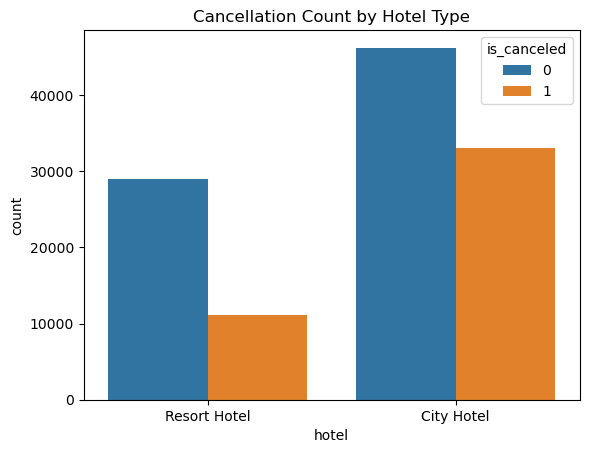

In [6]:
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title('Cancellation Count by Hotel Type')
plt.show()

### Price Fluctuation

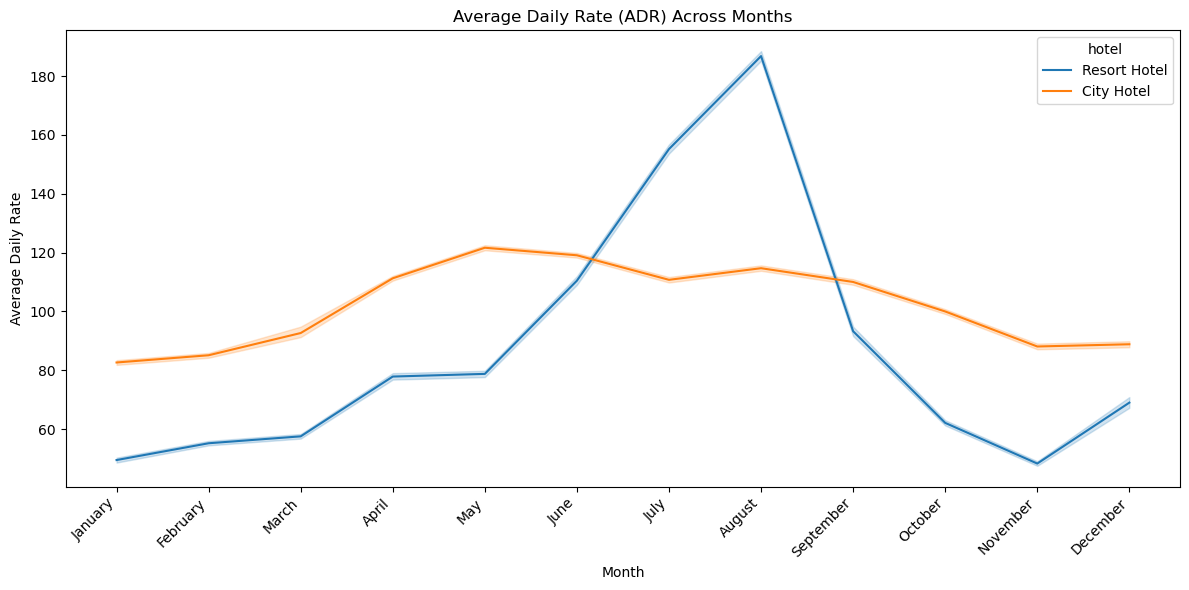

In [ ]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

# Convert the column to an ordered Categorical type
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=months, ordered=True)

plt.figure(figsize=(12, 6))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel', data=df)

plt.xticks(rotation=45, ha='right') 
plt.title('Average Daily Rate (ADR) Across Months')
plt.ylabel('Average Daily Rate')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

### Market Segmentation

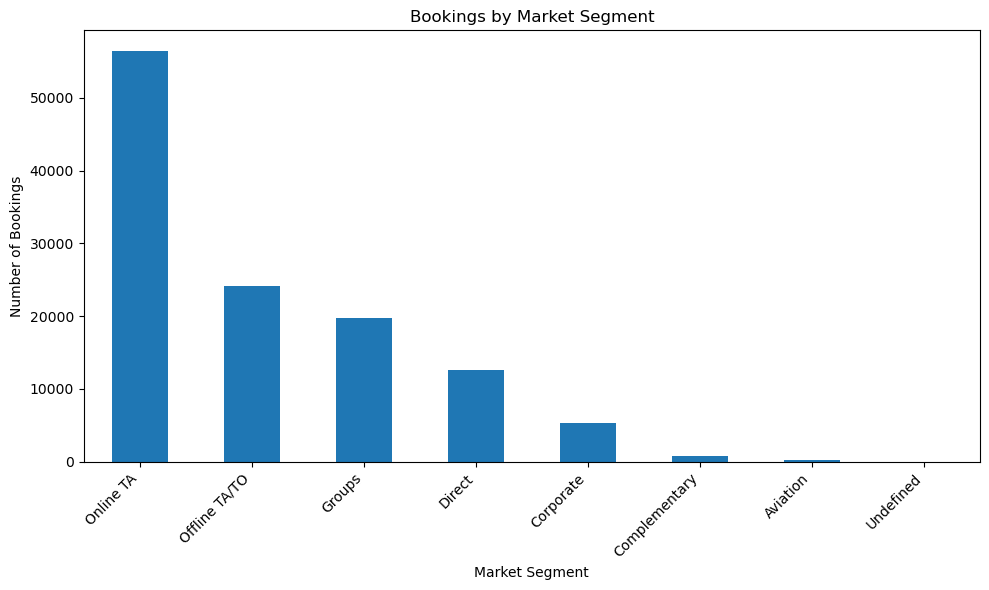

In [18]:
plt.figure(figsize=(10, 6))

market_counts = df['market_segment'].value_counts().plot(kind='bar')

plt.title('Bookings by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()